# SRN on panHelio
### Called by running the code directly
######  This is the "advanced user" version of the code


## Setup ------------------------------------------------------
This is just imports, path stuff, and helper functions

In [1]:
# Helpers
import os
changed=False

def where():
    print("Current Directory: \n{}".format(os.getcwd()))
    
def change_directory(directory, changed):

    dir_out=os.path.join(directory, "src")
    if not directory in os.getcwd():
        os.chdir(os.path.join(os.getcwd(), dir_out))
    if not changed:
        new_path = os.path.join(os.getcwd(), "..")
        os.chdir(new_path)
    changed=True
    where()


In [2]:
# Go where you need to go for the imports
if not changed:
    change_directory('sunback', changed)
    changed = True
    
new_path = os.path.abspath("/srv/data/shared/notebooks/cgilly/sunback/src")
os.chdir(new_path)    
    
# Imports
from fetcher.LocalFetcher import LocalSingleFetcher, LocalCdfFetcher
from processor.ImageProcessorCV import ImageProcessorCV #, ImageProcessorNetCDF
from processor.SRNSubProcessors import SRNSingleShotProcessor

from science.parameters import Parameters
from run import Runner, SingleRunner
import matplotlib.pyplot as plt
%matplotlib inline
# %matplotlib ipympl
# %matplotlib notebook
import xarray as xr

Current Directory: 
/srv/data/shared/notebooks/cgilly/sunback/src
/srv/data/shared/notebooks/cgilly/sunback/src
Cannot load backend 'Qt5Agg' which requires the 'qt5' interactive framework, as 'headless' is currently running


In [3]:
# Go to the directory with the single image
test_directory = r"/srv/data/shared/notebooks/cgilly/sunback/src/sunback_images/Single/"
# test_image = r"aia.lev1_euv_12s.2013-09-29T000009Z.304.image_lev1.fits"
test_image = r"AIA20210923_172100.nc"
test_path = os.path.join(test_directory, test_image)
os.chdir(test_directory)
where()
print("    ", os.path.basename(test_path))

Current Directory: 
/srv/data/shared/notebooks/cgilly/sunback/src/sunback_images/Single
     AIA20210923_172100.nc



## Set Parameters -------------------------------------------------------------------

Now we can set the program data. First you instantiate a Parameters object, then set a couple of settings.

In [4]:
p = Parameters()

p.use_image_path(test_path)
p.batch_name("Single")
p.do_single = True
p.run_type("Process a Single Image")
p.do_one(True, True)
p.is_debug(True)
p.destroy = False
p.confirm_save = True



Sunback works by using *processors* to sequentially modify images. There are many processors available in sunback. This example only uses three, but you can string together as many as you want. 

This is how you decide which processors you want to actually use:

In [5]:
# Set the Processesors
p.fetchers(LocalCdfFetcher,          rp=True)  # Get the desired file
    #^^ one of the main things that had to be modified ^^
    
p.processors([SRNSingleShotProcessor],  rp=True)  # Apply the SRN Filter
# p.putters([ImageProcessorNetCDF],           rp=True)  # Makes the PNGs from Fits

[processor.SRNSubProcessors.SRNSingleShotProcessor]


Processors that are dropped directly into the method run alone, while those nested inside a list will be appended to the current list of that type of processor. The rp parameter tells if the processor will be repeated on subsequent runs (Not super relevant to one-shots). Fetchers, processors, and putters are all child classes of Processor, with a couple of child-methods specific to each one added. 


         
## Run the Filter --------------------------------------------------------


Finally, you start the code. The Runner class will apply each of the selected processors to every fits file in a directory, whereas the SingleRunner will apply each processor to a single image without saving and loading. Support for doing all the steps to a single image at a time in a directory of many images is in-prep.

_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_
Starting Job: Single
_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_ 

>>-->>  Local Single CDF Fetcher: Load the image from Disk  <<--<<
 v Loading Local File...
   Looking in: 
     /srv/data/shared/notebooks/cgilly/sunback/src/sunback_images/Single
     for AIA20210923_172100.nc  at  20210923_172100

>>-->>  SRN Single Shot Processor: Create and Apply the Radial SRN Curves  <<--<<
 v  Processing Image...
   New CDF saved to 
    /srv/data/shared/notebooks/cgilly/sunback/src/sunback_images/Single/AIA20210923_172100_filtered.nc

   V Plotting Confirmation of Reduction:
      raw:



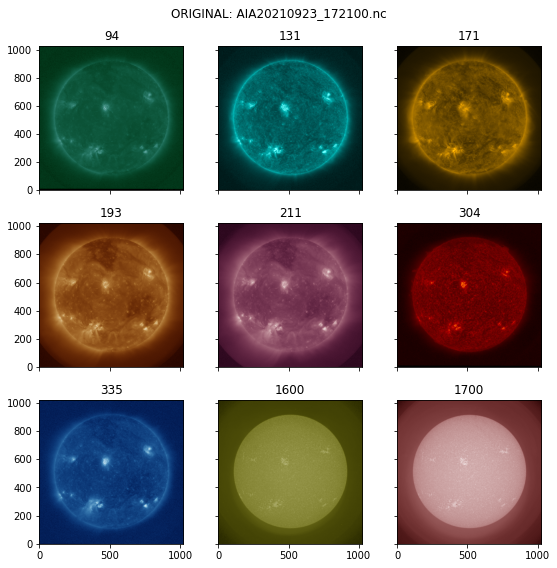

      Modified:



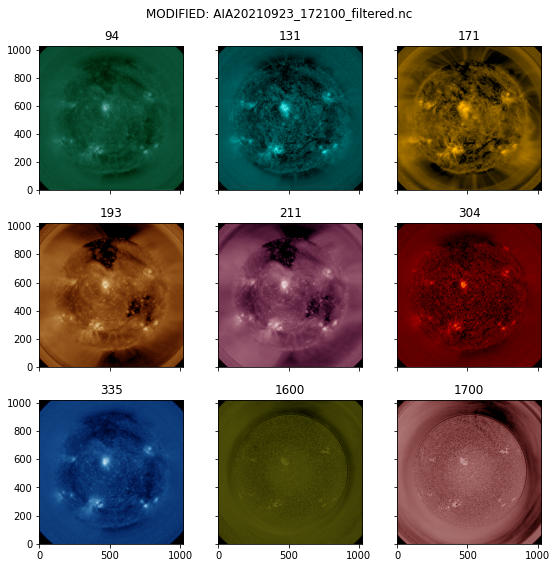

   ^ We Plotted!

 ^ Success!


>>-->>  NullPutter: Print the Name of the Image Folder  <<--<<
 /srv/data/shared/notebooks/cgilly/sunback/src/sunback_images/Single/sunback_images/Single



_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_
Program Complete in 0 minutes and 6 seconds. 
_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_-_



In [6]:
# Run the Code
SingleRunner(p).start(verb=False)